# Preliminary Data Exploration (NORMAL, BACTERIA, VIRUS)

In [1]:
import os

os.chdir("..")

In [2]:
!uv run src/data/download.py

In [3]:
from pathlib import Path
import pandas as pd


def load_image_paths(path: Path) -> pd.DataFrame:
    """
    Loads image paths and labels from the dataset.
    It handles the multiclass case (NORMAL, BACTERIA, VIRUS) by inspecting
    filenames to differentiate between bacterial and viral pneumonia.
    """
    image_data = []
    for class_path in path.iterdir():
        if not class_path.is_dir():
            continue

        dir_name = class_path.name
        for image_path in class_path.glob("*.jpeg"):
            label = None
            if dir_name == "NORMAL":
                label = "NORMAL"
            elif dir_name == "PNEUMONIA":
                if "bacteria" in image_path.name.lower():
                    label = "BACTERIA"
                elif "virus" in image_path.name.lower():
                    label = "VIRUS"

            if label:
                image_data.append({"path": image_path, "label": label})

    return pd.DataFrame(image_data)


data_path = Path("data/raw")
train_df = load_image_paths(data_path / "train")
test_df = load_image_paths(data_path / "test")

print(f"Found {len(train_df)} training images.")
print(f"Found {len(test_df)} testing images.")
train_df.head()

Found 5232 training images.
Found 624 testing images.


,path,label
0,data/raw/train/NORMAL/NORMAL-2692080-0001.jpeg,NORMAL
1,data/raw/train/NORMAL/NORMAL-996167-0001.jpeg,NORMAL
2,data/raw/train/NORMAL/NORMAL-8164108-0001.jpeg,NORMAL
3,data/raw/train/NORMAL/NORMAL-3860648-0002.jpeg,NORMAL
4,data/raw/train/NORMAL/NORMAL-3685250-0001.jpeg,NORMAL


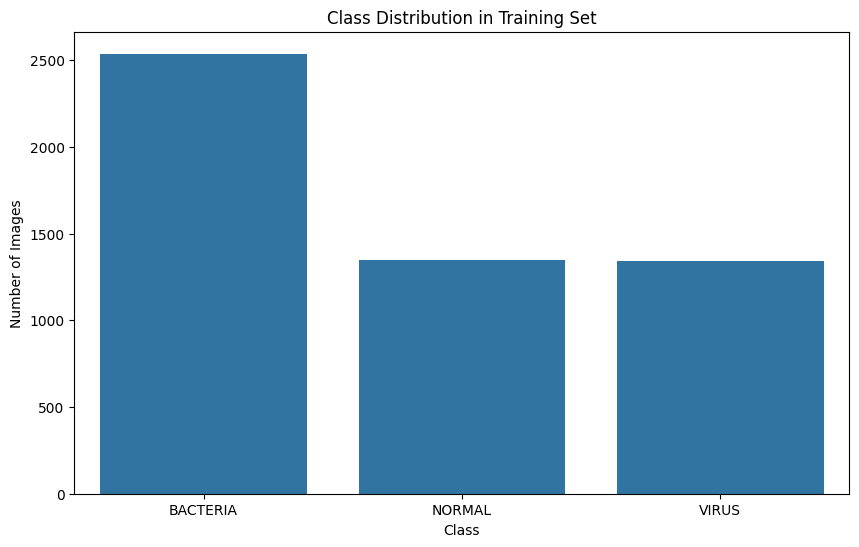

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(
    data=train_df, x="label", order=train_df["label"].value_counts().index
)
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show()

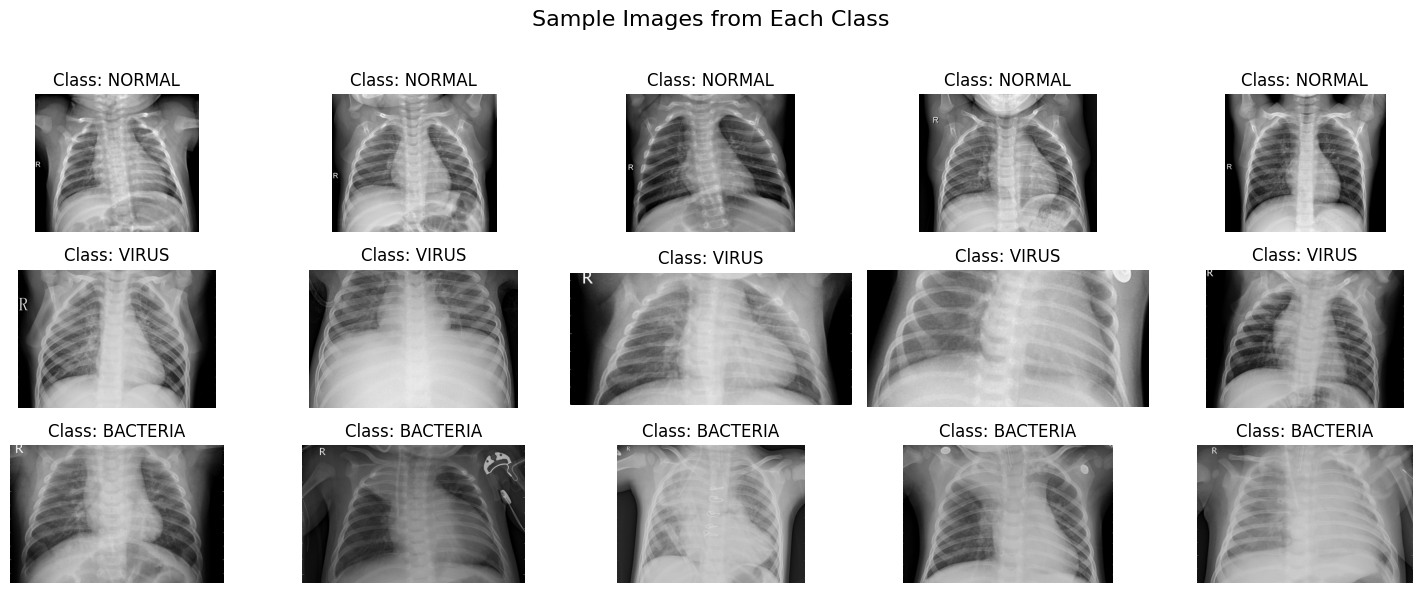

In [5]:
from PIL import Image


def show_sample_images(df: pd.DataFrame) -> None:
    labels = df["label"].unique()
    fig, axes = plt.subplots(len(labels), 5, figsize=(15, 2 * len(labels)))
    fig.suptitle("Sample Images from Each Class", fontsize=16)

    for i, label in enumerate(labels):
        sample_images = df[df["label"] == label].sample(5, random_state=42)
        for j, (_, row) in enumerate(sample_images.iterrows()):
            img = Image.open(row["path"]).convert("L")  # Convert to grayscale
            ax = axes[i, j]
            ax.imshow(img, cmap="gray")
            ax.set_title(f"Class: {label}")
            ax.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


show_sample_images(train_df)

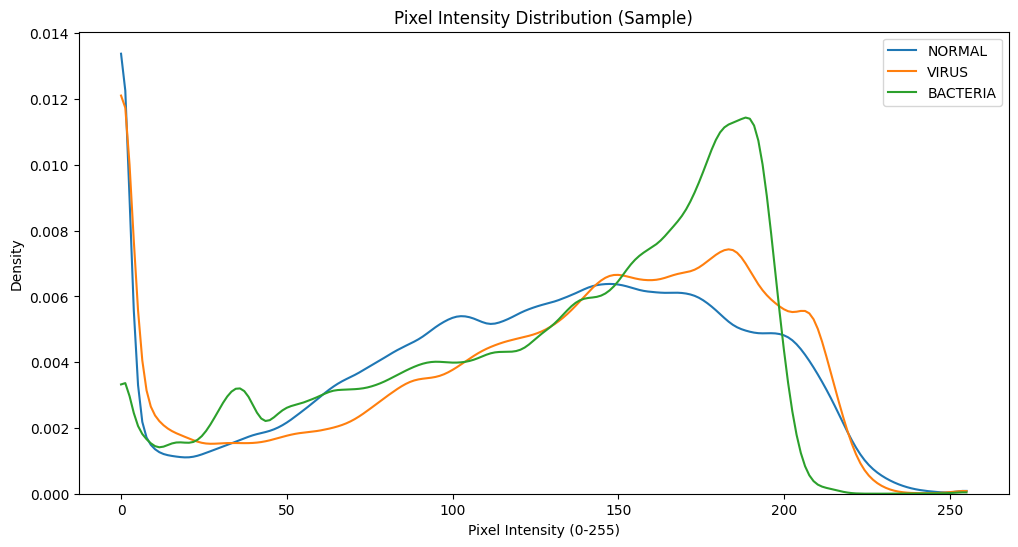

In [6]:
def plot_pixel_intensity_distribution(
    df: pd.DataFrame, n_samples: int = 5
) -> None:
    plt.figure(figsize=(12, 6))
    plt.title("Pixel Intensity Distribution (Sample)")
    plt.xlabel("Pixel Intensity (0-255)")
    plt.ylabel("Density")

    for label in df["label"].unique():
        sample_df = df[df["label"] == label].sample(
            min(n_samples, len(df[df["label"] == label])), random_state=42
        )
        intensities = []
        for path in sample_df["path"]:
            img = Image.open(path).convert("L")
            intensities.extend(img.get_flattened_data())

        sns.kdeplot(intensities, label=label, clip=(0, 255))

    plt.legend()
    plt.show()


plot_pixel_intensity_distribution(train_df)

Getting image sizes:   0%|          | 0/5232 [00:00<?, ?it/s]

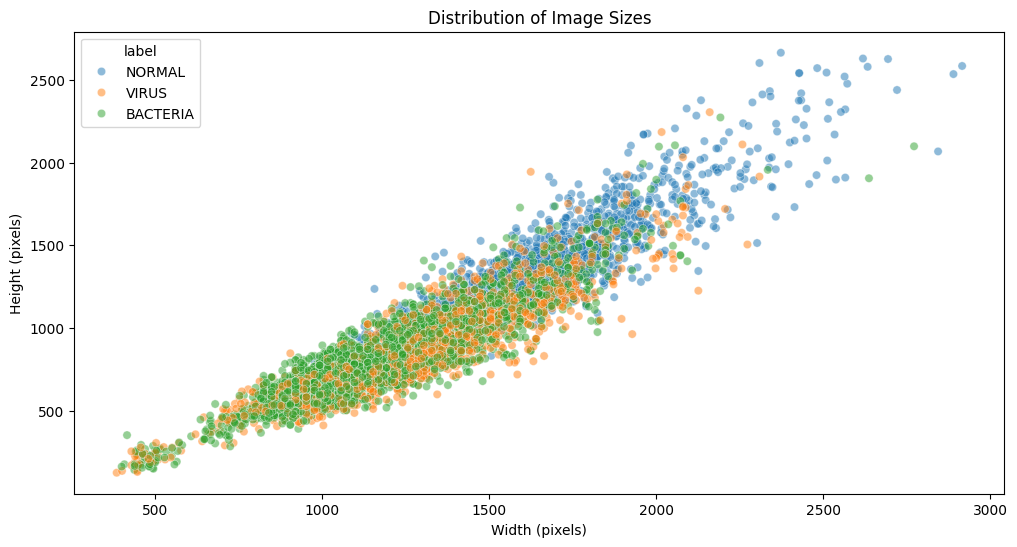

In [7]:
from tqdm.notebook import tqdm


def get_image_sizes(df: pd.DataFrame) -> pd.DataFrame:
    sizes = []
    for _, row in tqdm(
        df.iterrows(), total=len(df), desc="Getting image sizes"
    ):
        with Image.open(row["path"]) as img:
            sizes.append(img.size)
    size_df = pd.DataFrame(sizes, columns=["width", "height"])
    return pd.concat([df, size_df], axis=1)


train_df_sizes = get_image_sizes(train_df)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=train_df_sizes, x="width", y="height", hue="label", alpha=0.5
)
plt.title("Distribution of Image Sizes")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.show()

In [8]:
import numpy as np


def prepare_embedding_data(df, n_samples=1000, img_size=64):
    n_classes = df["label"].nunique()
    n_per_class = n_samples // n_classes
    sampled_indices = (
        df.groupby("label", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), n_per_class), random_state=42))
        .index
    )
    sampled = df.loc[sampled_indices].copy()

    image_vectors = []
    for p in tqdm(sampled["path"].values, desc="Loading Images"):
        img = Image.open(p).convert("L").resize((img_size, img_size))
        image_vectors.append(np.array(img).flatten())

    X = np.array(image_vectors) / 255.0
    y = sampled["label"].values

    return X, y


X_train, y_train = prepare_embedding_data(train_df, n_samples=1000)

Loading Images:   0%|          | 0/999 [00:00<?, ?it/s]

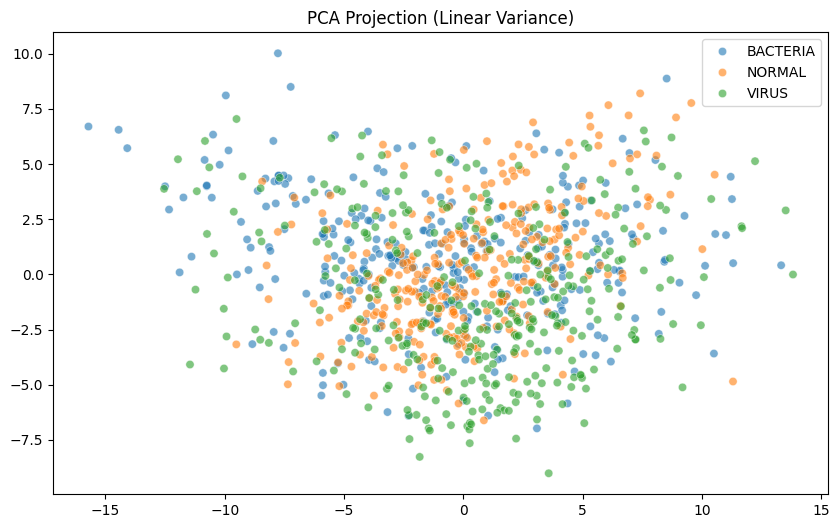

In [9]:
from sklearn.decomposition import PCA


def plot_pca(X, labels):
    pca_results = PCA(n_components=2, random_state=42).fit_transform(X)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=pca_results[:, 0],
        y=pca_results[:, 1],
        hue=labels,
        palette="tab10",
        alpha=0.6,
    )
    plt.title("PCA Projection (Linear Variance)")
    plt.show()


plot_pca(X_train, y_train)

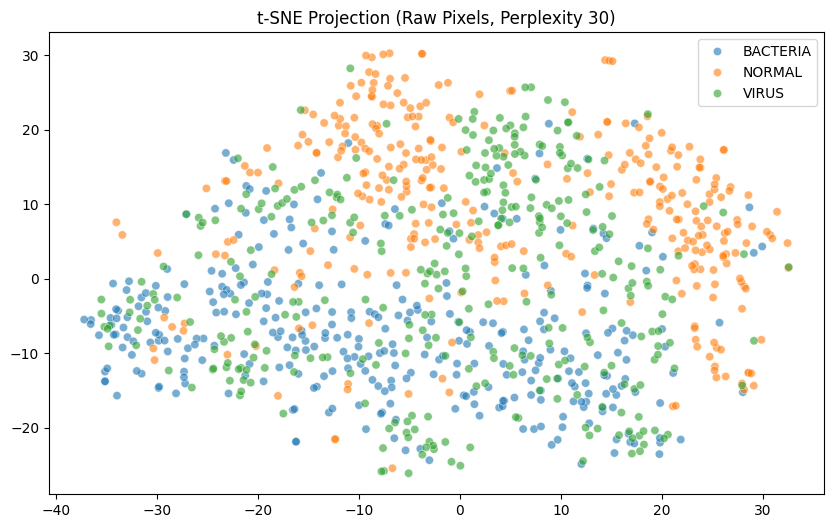

In [12]:
from sklearn.manifold import TSNE


def plot_tsne(X, labels, perplexity=30):
    tsne_results = TSNE(
        n_components=2, perplexity=perplexity, random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=tsne_results[:, 0],
        y=tsne_results[:, 1],
        hue=labels,
        palette="tab10",
        alpha=0.6,
    )
    plt.title(f"t-SNE Projection (Raw Pixels, Perplexity {perplexity})")
    plt.show()


plot_tsne(X_train, y_train)

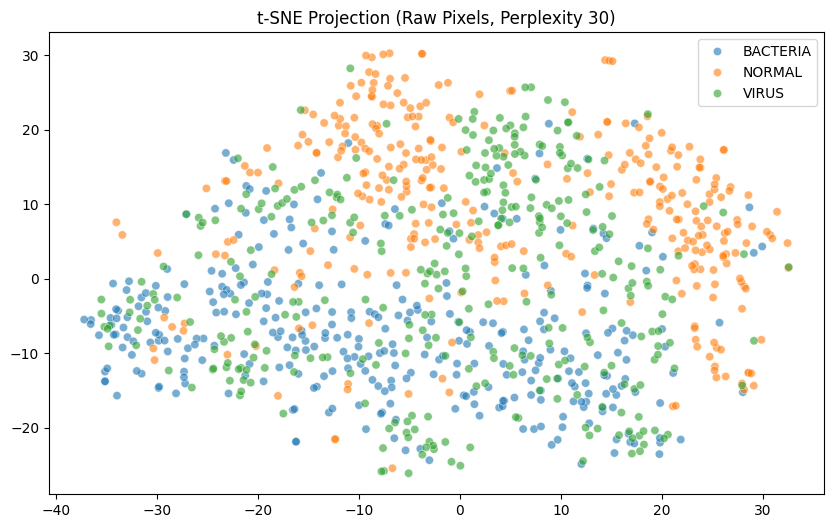

In [14]:
def plot_tsne(X, labels, perplexity=30):
    tsne_results = TSNE(
        n_components=2, perplexity=perplexity, random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=tsne_results[:, 0],
        y=tsne_results[:, 1],
        hue=labels,
        palette="tab10",
        alpha=0.6,
    )
    plt.title(f"t-SNE Projection (Raw Pixels, Perplexity {perplexity})")
    plt.show()


plot_tsne(X_train, y_train)

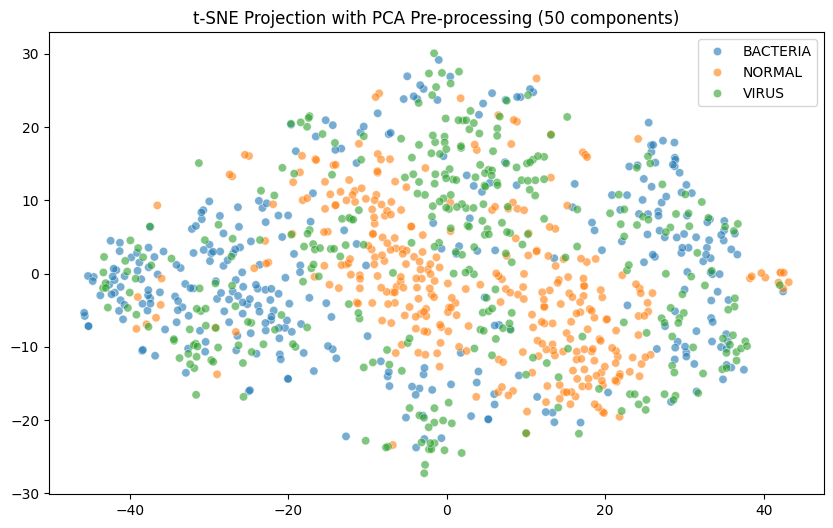

In [ ]:
def plot_pca_tsne_combined(X, labels, pca_comps=50, perplexity=30):
    X_reduced = PCA(n_components=pca_comps, random_state=42).fit_transform(X)
    tsne_results = TSNE(
        n_components=2, perplexity=perplexity, random_state=42
    ).fit_transform(X_reduced)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=tsne_results[:, 0],
        y=tsne_results[:, 1],
        hue=labels,
        palette="tab10",
        alpha=0.6,
    )
    plt.title(
        f"t-SNE Projection with PCA Pre-processing ({pca_comps} components)"
    )
    plt.show()


plot_pca_tsne_combined(X_train, y_train)

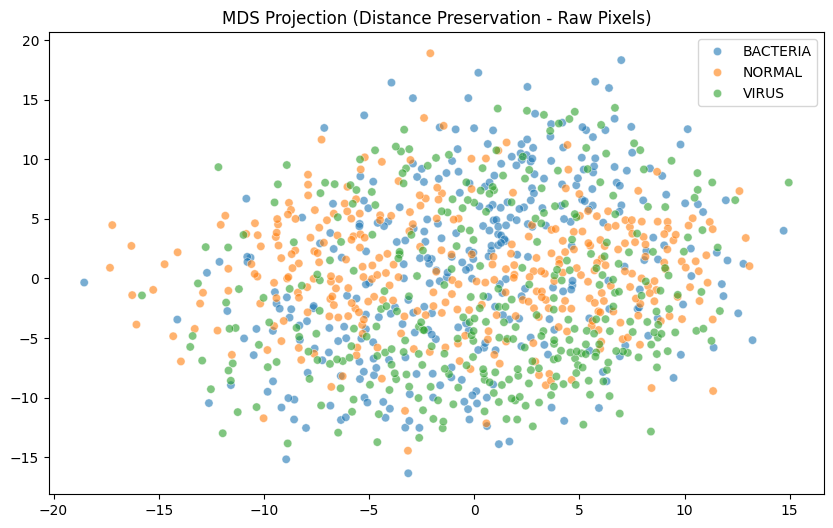

In [15]:
from sklearn.manifold import MDS


def plot_mds(X, labels):
    mds = MDS(
        n_components=2,
        random_state=42,
        normalized_stress="auto",
        n_init=4,
        init="random",
    )
    mds_results = mds.fit_transform(X)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=mds_results[:, 0],
        y=mds_results[:, 1],
        hue=labels,
        palette="tab10",
        alpha=0.6,
    )
    plt.title("MDS Projection (Distance Preservation - Raw Pixels)")
    plt.show()


plot_mds(X_train, y_train)

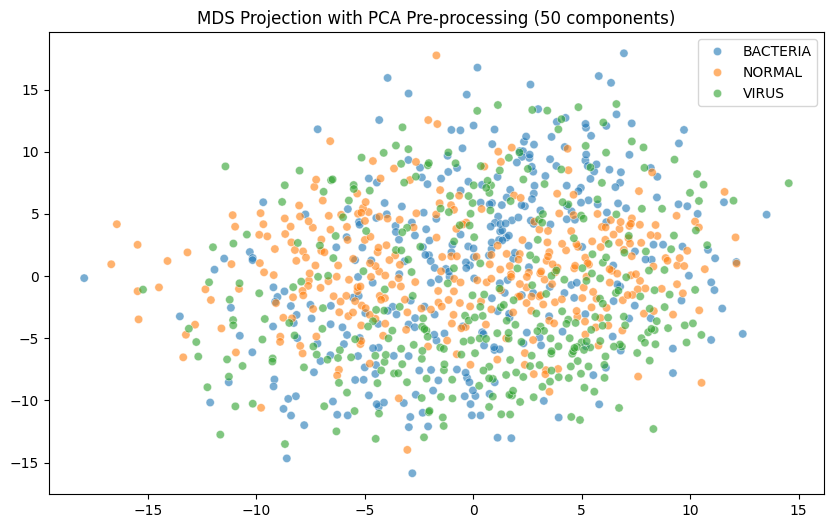

In [16]:
def plot_pca_mds_combined(X, labels, pca_comps=50):
    X_reduced = PCA(n_components=pca_comps, random_state=42).fit_transform(X)
    mds = MDS(
        n_components=2,
        random_state=42,
        normalized_stress="auto",
        n_init=4,
        init="random",
    )
    mds_results = mds.fit_transform(X_reduced)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=mds_results[:, 0],
        y=mds_results[:, 1],
        hue=labels,
        palette="tab10",
        alpha=0.6,
    )
    plt.title(
        f"MDS Projection with PCA Pre-processing ({pca_comps} components)"
    )
    plt.show()


plot_pca_mds_combined(X_train, y_train)

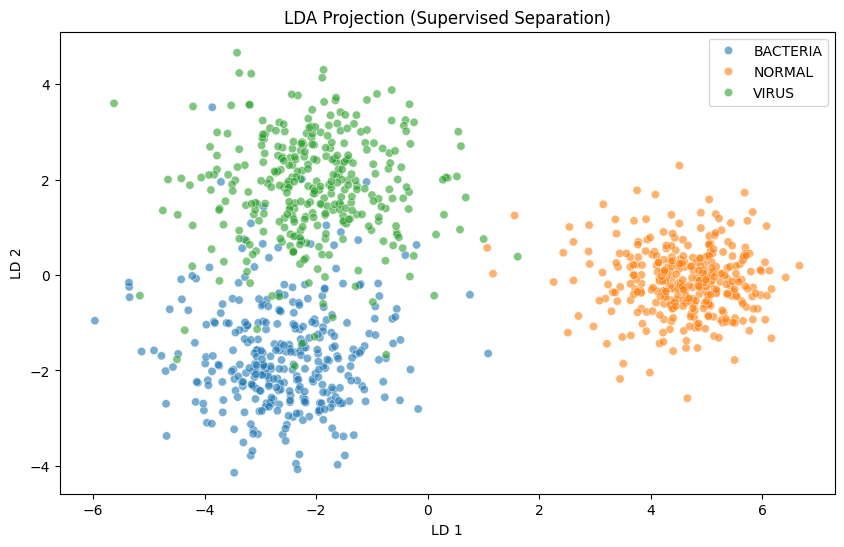

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


def plot_lda(X, labels):
    lda = LinearDiscriminantAnalysis(n_components=2)
    lda_results = lda.fit_transform(X, labels)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=lda_results[:, 0],
        y=lda_results[:, 1],
        hue=labels,
        palette="tab10",
        alpha=0.6,
    )
    plt.title("LDA Projection (Supervised Separation)")
    plt.xlabel("LD 1")
    plt.ylabel("LD 2")
    plt.show()


plot_lda(X_train, y_train)